In [ ]:
## Embeddings : vector representation oof text
[0.9, 9, 8, 6]

In [ ]:
# Indexing : It is the process of organizing data data to enable
#            faster search/retrieval of data.

In [ ]:
## Flat Indexing :
# Check similarity of query with each chunk

In [ ]:
## Approximate nearest neighbors :

In [ ]:
# IVF

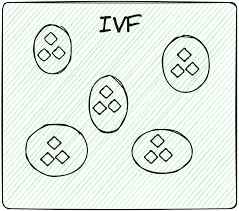

In [1]:
from IPython.display import Image
Image("/content/IVF.jpg")

In [ ]:
15

5 + 3 = 8

In [ ]:
## Query :
--> Check similarity of query with centroid of each cluster
--> then find most similar cluster
--> check similarity with each chunk in that cluster

####Hierachical Nevigable Small World (HNSW) :

In [ ]:
# HNSW is inspired by :
    -- Skip-list
    -- Nevigable Search World

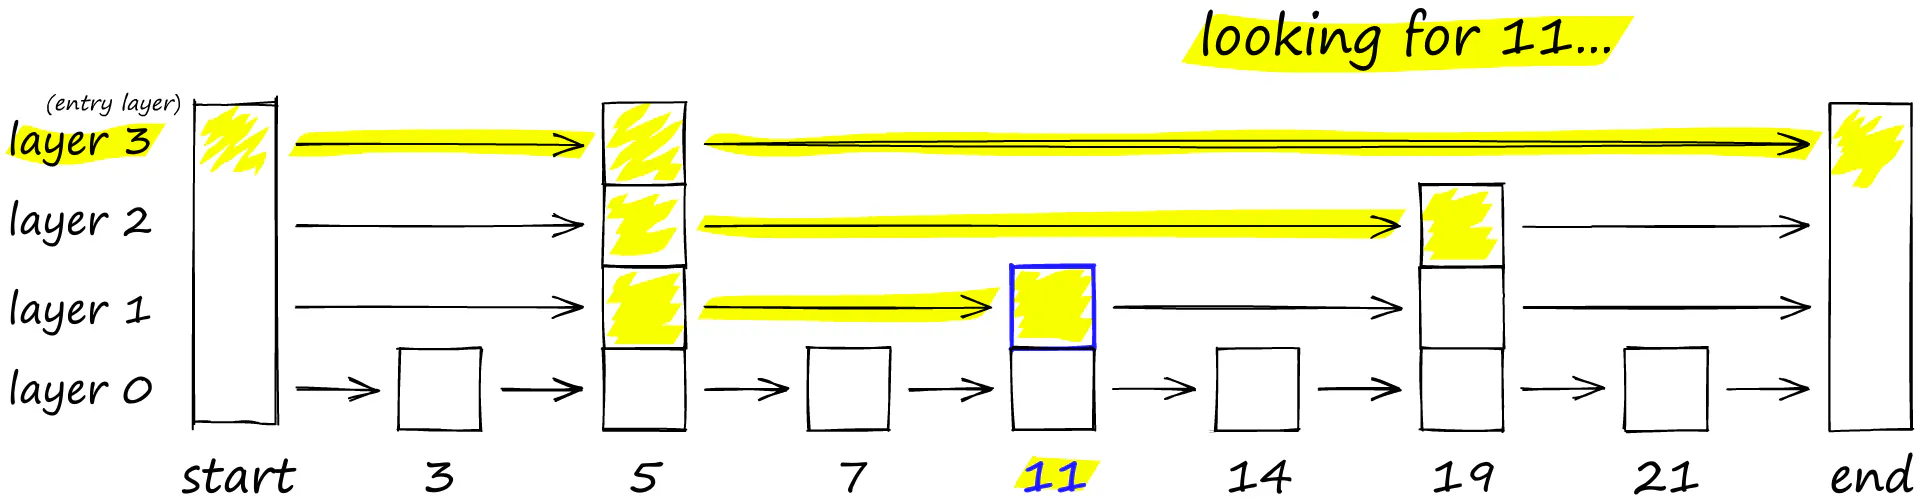

In [2]:
## Skip-List :
Image("/content/skip-list.jpg")

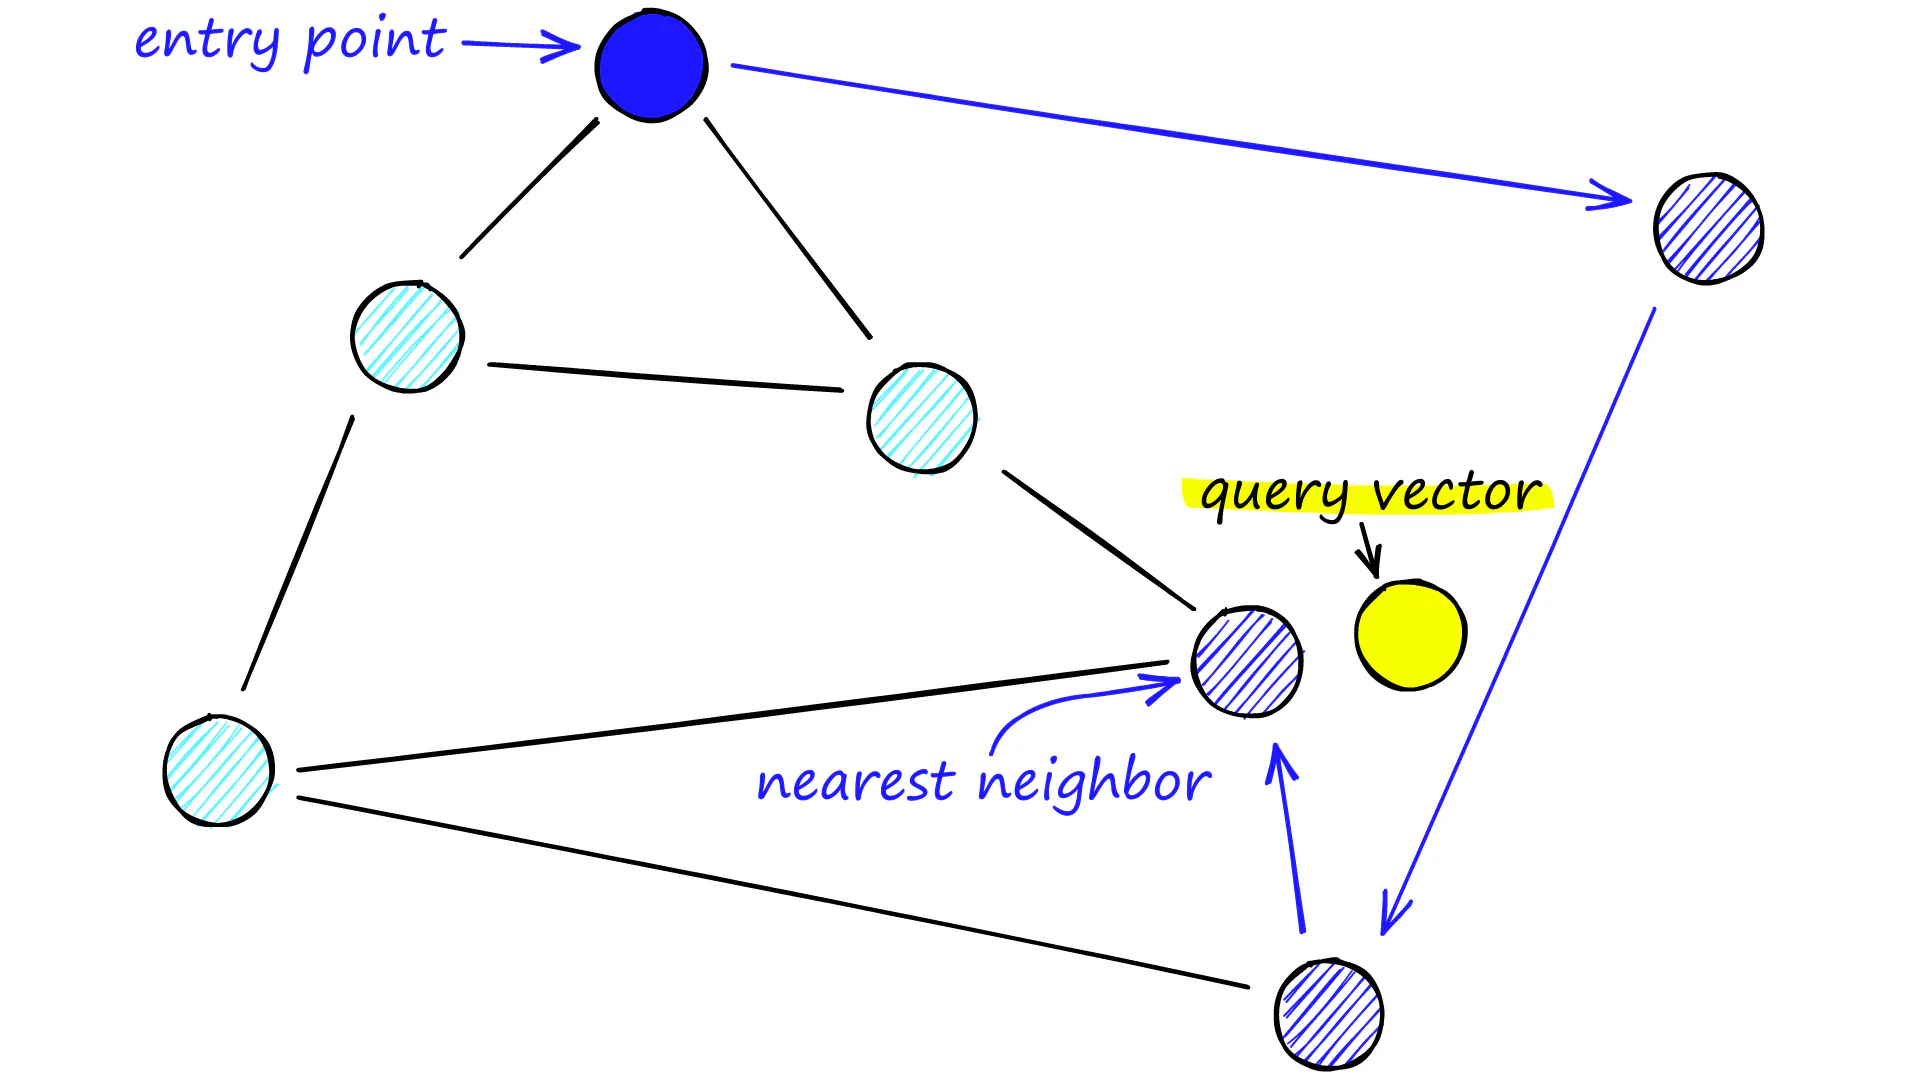

In [5]:
## Navigable Small World
Image("/content/NSW.jpg", width=300)

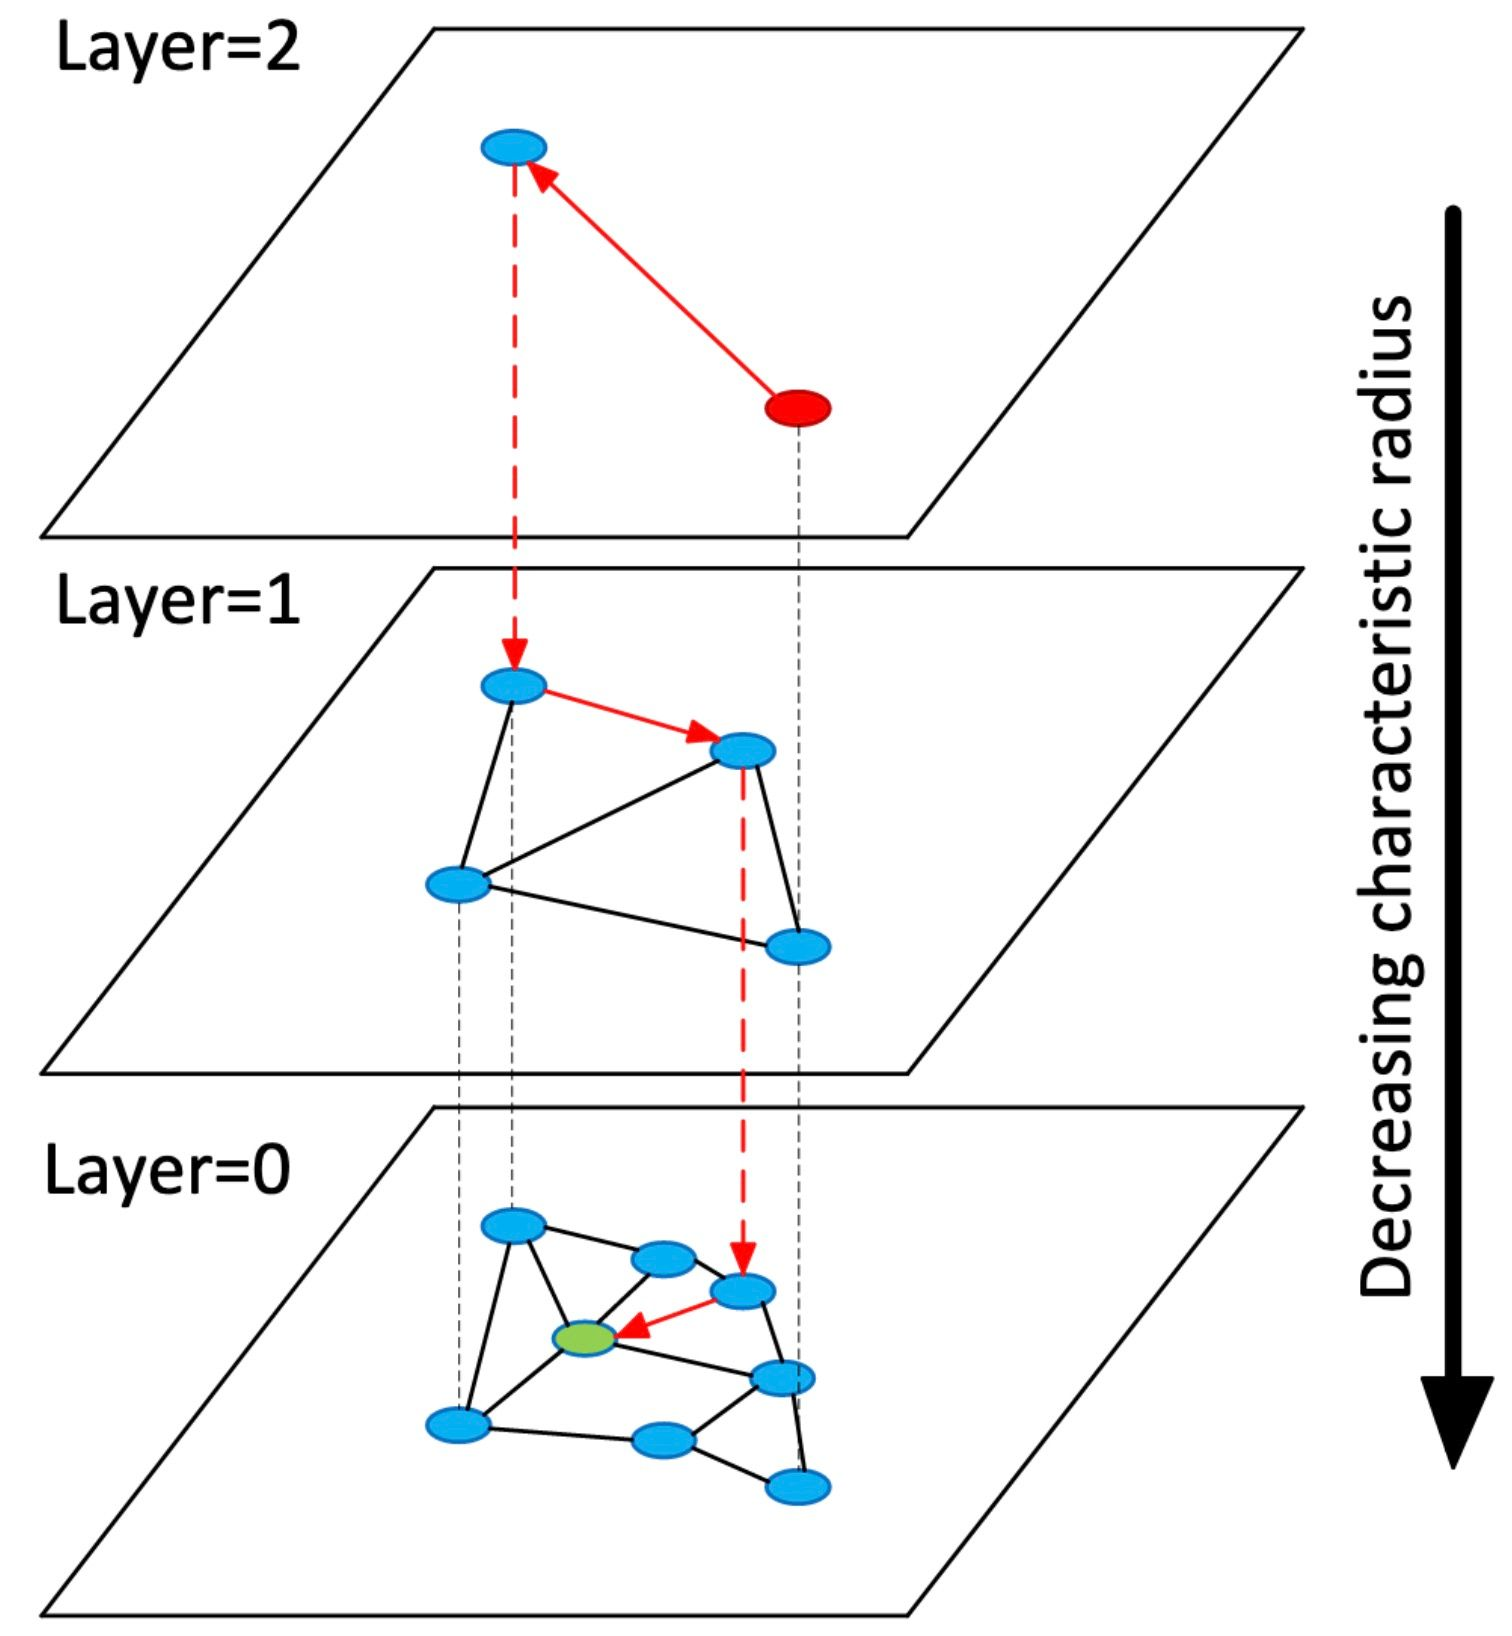

In [9]:
# Hierachical Nevigable Small World (HNSW) :
Image("/content/hnsw.jpg", width=200)

####Reranker :

In [ ]:
## 2 Steps :
1. Retrive chunks using retriver (5)
2. Rerank retrived chunks using reranker

In [ ]:
## Cohereranker :

In [ ]:
A  --> 0.6
B  --> 0.8
C  --> 0.7
D  --> 0.6
E  --> 0.5

In [ ]:
from re import A
## Rerank (rearrage according to relevecy score )
B
C
A
D
E

In [13]:
!pip install langchain-classic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.3/554.3 kB 20.6 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.0
    Uninstalling langchain-core-1.4.0:
      Successfully uninstalled langchain-core-1.4.0


In [16]:
!pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [17]:
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker

/tmp/ipykernel_4050/2882293476.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.cross_encoders import HuggingFaceCrossEncoder


In [19]:
reranker_model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

In [20]:
reranker = CrossEncoderReranker(model=reranker_model)

In [ ]:
reranker_retriver = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=retriever
)